In [ ]:
# Financial Sentiment Analysis

## Project Overview

# This project analyzes financial text and classifies its sentiment as **Positive, Negative, or Neutral**.

# Two approaches are compared:

# 1. Traditional Machine Learning: TF-IDF + Logistic Regression
# 2. Pre-trained Financial Language Model: FinBERT

#  The models are evaluated using **Accuracy, Precision, Recall, F1-score, and Confusion Matrix** to determine which approach performs better.

In [70]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from transformers import pipeline

In [71]:
# 2. Load Dataset
df = pd.read_csv("data.csv")

df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [72]:
# 3. Basic Information
df.shape
df.columns
df.isnull().sum()

Sentence     0
Sentiment    0
dtype: int64

In [74]:
# 4. Sentiment Distribution
df["Sentiment"].value_counts()

Sentiment
neutral     3130
positive    1852
negative     860
Name: count, dtype: int64

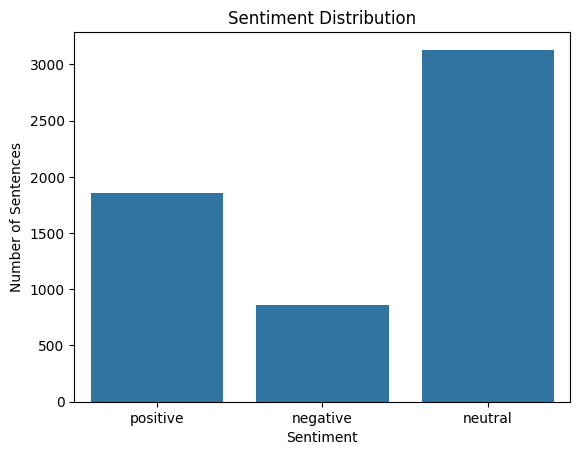

In [75]:
# 5. Visualization
sns.countplot(data=df, x="Sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Sentences")
plt.show()

In [76]:
# 6. Defining X  & y
X = df["Sentence"]
y = df["Sentiment"]

In [77]:
# 7. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4673
Testing samples: 1169


In [78]:
# 8. TF-IDF
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4673, 10099)
Testing TF-IDF shape: (1169, 10099)


In [79]:
# 9. Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

In [80]:
# 10. Baseline Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print()
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.699743370402053

              precision    recall  f1-score   support

    negative       0.31      0.13      0.18       172
     neutral       0.71      0.88      0.79       626
    positive       0.76      0.66      0.71       371

    accuracy                           0.70      1169
   macro avg       0.59      0.56      0.56      1169
weighted avg       0.67      0.70      0.67      1169



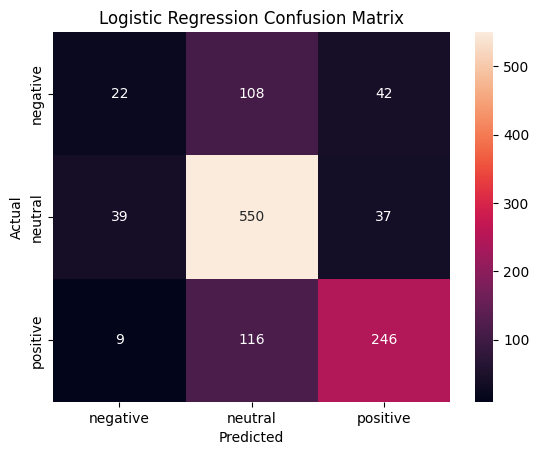

In [81]:
# 11. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [82]:
# 12. Balanced Logistic Regression
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_balanced.fit(X_train_tfidf, y_train)

y_pred_balanced = model_balanced.predict(X_test_tfidf)

In [83]:
# 13. Evaluate Balanced Model
balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print("Balanced Logistic Regression Accuracy:", balanced_accuracy)
print()
print(classification_report(y_test, y_pred_balanced))

Balanced Logistic Regression Accuracy: 0.688622754491018

              precision    recall  f1-score   support

    negative       0.39      0.51      0.44       172
     neutral       0.79      0.72      0.75       626
    positive       0.71      0.72      0.71       371

    accuracy                           0.69      1169
   macro avg       0.63      0.65      0.64      1169
weighted avg       0.71      0.69      0.70      1169



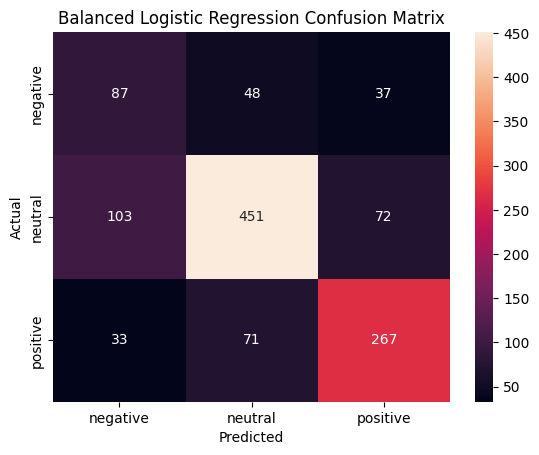

In [84]:
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Logistic Regression Confusion Matrix")
plt.show()

In [85]:
# 14. FinBERT
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert"
)

Device set to use cpu


In [86]:
# 15. Example Prediction
text = "The company's profits increased significantly this quarter."

result = finbert(text)

print(result)

[{'label': 'positive', 'score': 0.9579817056655884}]


In [87]:
# 16. FinBERT Full Test Predictions
finbert_predictions = []

for i in range(0, len(X_test), 16):
    batch = X_test.iloc[i:i+16].tolist()
    results_batch = finbert(batch)
    
    finbert_predictions.extend(
        [result["label"] for result in results_batch]
    )

print("Predictions completed:", len(finbert_predictions))

Predictions completed: 1169


In [88]:
# 17. FinBERT Evaluation
finbert_accuracy = accuracy_score(
    y_test,
    finbert_predictions
)

print("FinBERT Accuracy:", finbert_accuracy)
print()
print(classification_report(
    y_test,
    finbert_predictions
))

FinBERT Accuracy: 0.7510692899914457

              precision    recall  f1-score   support

    negative       0.48      0.80      0.60       172
     neutral       0.82      0.75      0.78       626
    positive       0.86      0.74      0.79       371

    accuracy                           0.75      1169
   macro avg       0.72      0.76      0.73      1169
weighted avg       0.79      0.75      0.76      1169



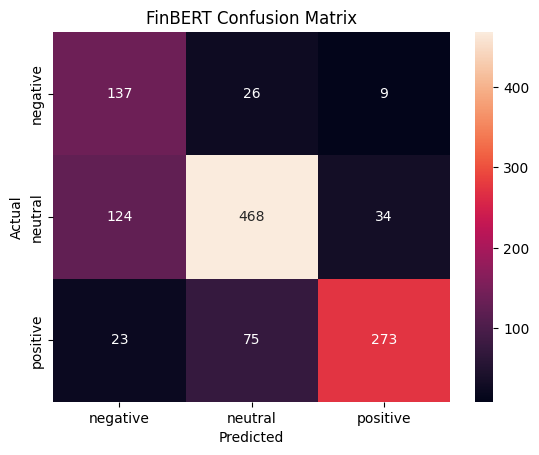

In [89]:
cm_finbert = confusion_matrix(
    y_test,
    finbert_predictions
)

sns.heatmap(
    cm_finbert,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FinBERT Confusion Matrix")
plt.show()

In [93]:
# 18. Final Comparison
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "FinBERT"
    ],
    "Accuracy": [
        accuracy,
        balanced_accuracy,
        finbert_accuracy
    ],
    "Macro F1": [
        baseline_f1,
        balanced_f1,
        finbert_f1
    ]
})

results

,Model,Accuracy,Macro F1
0,Logistic Regression,0.699743,0.558143
1,Balanced Logistic Regression,0.688623,0.636515
2,FinBERT,0.751069,0.726300


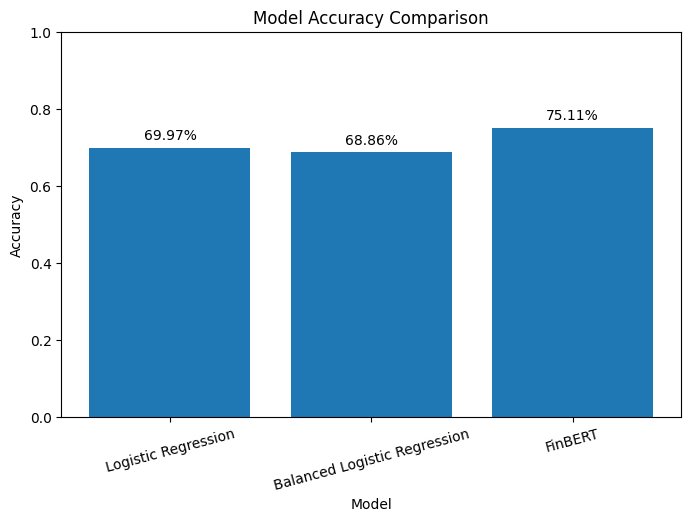

In [91]:
# 19. Visualization
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

for i, score in enumerate(results["Accuracy"]):
    plt.text(
        i,
        score + 0.02,
        f"{score:.2%}",
        ha="center"
    )

plt.xticks(rotation=15)
plt.show()

In [ ]:
# Conclusion

#This project evaluated three approaches for financial sentiment classification: TF-IDF with Logistic Regression, Balanced Logistic Regression, 
# and FinBERT. FinBERT achieved the highest performance with approximately 75.1% accuracy and a 0.73 macro F1-score, outperforming the traditional
# machine-learning baseline. The results demonstrate the advantage of using a domain-specific pretrained language model for financial sentiment analysis.

In [94]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [95]:
%%writefile inference.py

import joblib

# Load saved model and TF-IDF vectorizer
model = joblib.load("sentiment_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# New financial sentence
text = input("Enter a financial sentence: ")

# Convert text into TF-IDF
text_tfidf = vectorizer.transform([text])

# Predict sentiment
prediction = model.predict(text_tfidf)

print("Predicted Sentiment:", prediction[0])

Writing inference.py


In [97]:
!python inference.py

^C
